### Problem Statement

This project implements the robust portfolio selection framework from Goldfarb and Iyengar (2002). The goal is to compute an optimal asset allocation that is resilient to the statistical estimation errors inherent in historical financial data.

The problem is formulated as finding the **Robust Maximum Sharpe Ratio** portfolio. This formulation maximizes the portfolio's return per unit of risk under the worst-possible realization of the model parameters within their statistically determined uncertainty sets.

---
### Constants & Hyperparameters

These are the fixed, user-defined inputs that structure the model environment.

| Symbol | Definition | Value in Project |
| :--- | :--- | :--- |
| $n$ | **Number of Assets** in the investment universe. | 424 |
| $m$ | **Number of Factors** in the linear return model. | 1 (SPY index) |
| $p$ | **Number of Observations** (trading days) in the training set. | 2514 |
| $\omega$ | **Confidence Level** probability for constructing uncertainty sets. | 0.95 (95%) |
| $r_f$ | **Risk-Free Rate** (annualized) used to calculate excess returns. | 0.0363 (3.63%) |
| $\Delta t$| **Time Step**, the fraction of a year representing one trading day. | $1/252$ |

---
### Given (Parameters)

The optimization problem is formulated using parameters derived from a historical training dataset (2014-2023). We adopt the **factor model** from the paper, where the return of each asset $i$ is defined as:

$$r_i = \mu_i + V_i^T f + \epsilon_i$$

Here, $r_i$, $f$, and $\mu_i$ are all defined as **annualized excess growth rates**. The parameters for this model are not known with certainty and are estimated from the data, resulting in the following inputs for the robust problem:

* **Point Estimates (The "Center" of our Beliefs):**
    * $\mu_0 \in \mathbb{R}^n$: The vector of estimated mean annualized excess growth rates (the regression intercepts).
    * $V_0 \in \mathbb{R}^n$: The vector of estimated factor loadings (the regression slopes, as $m=1$).
    * $F \in \mathbb{R}$: The scalar variance of the factor's excess growth rate, $\text{Var}(f)$. Following the paper's main model, $F$ is assumed to be a known, stable point estimate.

* **Uncertainty Sets (The "Bounds" of our Beliefs):**
    * **$S_m$ (Mean Uncertainty):** The set for the true mean $\mu$. It is defined as a "box" centered at $\mu_0$ with a radius defined by $\gamma \in \mathbb{R}^n$:
        $$S_m = \{\mu \in \mathbb{R}^n : |\mu_i - \mu_{0,i}| \le \gamma_i, \quad \forall i=1, ..., n\}$$
    * **$S_v$ (Factor Loading Uncertainty):** The set for the true factor loading $V$. It is defined as an "elliptical" region centered at $V_0$ with a radius defined by $\rho \in \mathbb{R}^n$:
        $$S_v = \{V \in \mathbb{R}^n : V = V_0 + W, \quad \|W_i\|_g \le \rho_i, \quad \forall i=1, ..., n\}$$
    * **$S_d$ (Residual Variance Uncertainty):** The set for the true residual variance $D$. It is defined as an "interval" for which we use the worst-case (upper) bound, $\overline{D} \in \mathbb{R}^{n \times n}$:
        $$S_d = \{D : D = \text{diag}(d), \quad \underline{d}_i \le d_i \le \overline{d}_i, \quad \forall i=1, ..., n\}$$

* **Model Simplification Parameters:**
    * $\kappa \in \mathbb{R}$: A scalar parameter, $1/(p-1)$, used in the simplified SOCP constraint for $S_v$.

---
### Optimization Variables (To Be Determined)

These are the decision variables solved for by the optimizer.

| Symbol | Definition |
| :--- | :--- |
| $\phi$ | The $n \times 1$ vector of **portfolio weights** (allocations), constrained such that $\phi_i \ge 0, \forall i=1, ..., n$. |
| $\nu$ | A scalar auxiliary variable representing the worst-case **factor standard deviation**. |
| $\delta$ | A scalar auxiliary variable representing the worst-case **residual variance**. |

---
### Objective

The conceptual objective is to solve the max-min problem for the Robust Sharpe Ratio over all defined uncertainty sets:

$$\max_{\phi} \min_{\mu \in S_m, V \in S_v, D \in S_d} \left\{ \frac{\mu^T \phi}{\sqrt{\phi^T(V^T F V + D)\phi}} \right\}$$

By assuming the optimal worst-case Sharpe ratio is strictly positive and utilizing the homogeneity of the objective function, this is transformed into the following equivalent convex Second-Order Cone Program (SOCP).

The implemented objective is to **minimize the total worst-case variance** subject to the robust counterpart for each uncertainty set:

$$\min_{\phi, \nu, \delta} \quad \nu^2 + \delta$$
$$\text{subject to:}$$
$$(\mu_0 - \gamma)^T \phi \ge 1 \quad\quad\quad\quad \text{(Robust counter-part for } S_m\text{)}$$
$$\phi^T \overline{D} \phi \le \delta \quad\quad\quad\quad \text{(Robust counter-part for } S_d\text{)}$$
$$\|F^{1/2} V_0 \phi\|_2 + \sqrt{\kappa} \rho^T \phi \le \nu \quad \text{(Robust counter-part for } S_v\text{, simplified model)}$$
$$\phi_i \ge 0, \quad \forall i=1, ..., n$$

### Step 1: Initialize Project Environment
This cell executes the `include.jl` script. This script is responsible for activating the project's Julia environment and loading all required packages, such as `JuMP` for optimization, `GLM` for regression, and `Plots` for visualization.

In [1]:
# Load the custom module from your first notebook
include("include.jl");

### Step 2: Load Training Data
Here, we load the raw daily price data from our custom `MyPortfolioDataSet()` function. We then extract the `train_dataset` which contains data from 2014 to 2023. This data has already been filtered in a previous notebook to ensure all tickers have a complete price history.

In [2]:
# Load the raw data
data = MyPortfolioDataSet()
train_dataset = data["train_dataset"];;

### Step 3: Find Maximum Trading Days
To ensure data integrity for our regression model, we must use a consistent data length. We retrieve the number of trading days from our `train_dataset` (using `AAPL` as a reference, as all tickers in this set have the same length).

In [3]:
maximum_number_trading_days = train_dataset["AAPL"] |> nrow;

### Step 4: Collect All Asset Tickers
We create a complete, sorted list of all asset tickers that are present in our filtered training dataset. This list will serve as the universe of assets for our optimization.

In [4]:
list_of_all_tickers = keys(train_dataset) |> collect |> x->sort(x)

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Step 5: Define Asset and Factor Universe
We define the final set of assets to be used in the model. `assets_to_use` is set to the entire list of 424 tickers. We also explicitly define our single market factor, `SPY`, which aligns with the factor model approach $r = \mu + V^T f + \epsilon$ described in the paper.

In [5]:
# --- Define our asset universe for this project ---
# We select a few representative tickers from your list of 424
assets_to_use = list_of_all_tickers
n = length(assets_to_use) # Number of assets

# Define the market factor
factor_ticker = "SPY"
m = 1; # Number of factors

### Step 6: Define the Growth Rate Function
This cell defines the `log_return_matrix` function. This function is central to our analysis and is designed to take the raw price data and, for each asset, calculate its **annualized excess growth rate**. As requested, it computes the log-return ($\ln(S_2/S_1)$), annualizes it (by dividing by $\Delta t$), and subtracts the annual risk-free rate.

In [6]:
"""
Calculates the annualized excess log-return matrix (growth rates).
"""
function log_return_matrix(dataset::Dict{String, DataFrame}, 
    firms::Array{String,1}; Δt::Float64 = (1.0/252.0), risk_free_rate::Float64 = 0.0)::Array{Float64,2}

    # initialize -
    # We use the first firm in the list to get row count
    number_of_firms = length(firms);
    number_of_trading_days = nrow(dataset[firms[1]]); 
    return_matrix = Array{Float64,2}(undef, number_of_trading_days-1, number_of_firms);

    # main loop -
    for i ∈ eachindex(firms) 

        # get the firm data -
        firm_index = firms[i];
        firm_data = dataset[firm_index];

        # compute the log returns -
        for j ∈ 2:number_of_trading_days
            S₁ = firm_data[j-1, :volume_weighted_average_price];
            S₂ = firm_data[j, :volume_weighted_average_price];
            return_matrix[j-1, i] = (1/Δt)*log(S₂/S₁) - risk_free_rate;
        end
    end

    # return -
    return return_matrix;
end

# --- Define Annual Risk-Free Rate ---
r_f_annual = 0.0363 # 3.63% 1-year T-Bill 

# --- Calculate Growth Rates ---
# Note: We pass the *annual* rate to the function
asset_growth_rates = log_return_matrix(train_dataset, assets_to_use, risk_free_rate = r_f_annual)
factor_growth_rates = log_return_matrix(train_dataset, [factor_ticker], risk_free_rate = r_f_annual)

# Get number of observations (days) from the result
p = size(asset_growth_rates, 1);

### Step 7: Calculate Training Set Growth Rates
Using the function from the previous step, we now calculate the annualized excess growth rates for two separate groups:
1.  **`asset_growth_rates`**: A $p \times n$ matrix (2514x424) for our $n$ assets.
2.  **`factor_growth_rates`**: A $p \times m$ matrix (2514x1) for our $m$ factors.

These two matrices serve as the dependent ($r$) and independent ($f$) variables for our regression. Here you can adjust `ω` to control the level of robustness. 

In [7]:
# --- 1. Set up regression inputs ---
# f is now the annualized excess return of the factor
f = factor_growth_rates[:, 1] 
A = [ones(p) f] # Design matrix A = [1 B^T]

# --- 2. Set Confidence Level ---
ω = 0.05 # Change this to your desired confidence level
c_J_mean = quantile(FDist(1, p-m-1), ω) # For J=1 (mean)
c_J_factor = quantile(FDist(m, p-m-1), ω) # For J=m (factor)

# --- 3. Pre-calculate regression-related matrices ---
A_inv = inv(A'A)
A_inv_11 = A_inv[1, 1] # For γ (mean uncertainty)

# --- 4. Initialize parameter vectors ---
# These parameters are now all on an *annualized* basis
μ₀ = Vector{Float64}(undef, n) # Asset's alpha
V₀ = Vector{Float64}(undef, n) # Asset's beta
γ = Vector{Float64}(undef, n)  # Uncertainty in alpha
ρ = Vector{Float64}(undef, n)  # Uncertainty in beta
D_bar = Vector{Float64}(undef, n) # Annualized residual variance

# --- 5. Run regression for each asset ---
for (i, ticker) in enumerate(assets_to_use)
    # y is now the annualized excess return of the asset
    y = asset_growth_rates[:, i]
    
    model = lm(A, y)
    params = coef(model)
    μ₀[i] = params[1]
    V₀[i] = params[2]
    
    s_i_squared = deviance(model) / dof_residual(model)
    D_bar[i] = s_i_squared
    
    # Calculate uncertainty bounds per (62) and (63)
    γ[i] = sqrt(A_inv_11 * c_J_mean * s_i_squared) 
    ρ[i] = sqrt(m * c_J_factor * s_i_squared)
end


# --- 6. Calculate Factor & Model Simplification Parameters ---
F = var(f) # Annualized variance of the factor's excess return
κ = 1.0 / (p - 1);

### Step 8: Estimate Robust Model Parameters
This is the core of the **"Recipe"** from **Section 5** of the paper. We perform a linear regression for each of the $n$ assets against the factor $f$ to find the parameters of the model $r = \alpha + \beta f + \epsilon$ (where $\alpha$ is $\mu_0$ and $\beta$ is $V_0$).

* We estimate the "point" parameters: $\mu_0$ (alpha), $V_0$ (beta), and $\overline{D}$ (residual variance).
* We then calculate the size of the uncertainty sets: $\gamma$ (for $\mu_0$) and $\rho$ (for $V_0$), based on our $\omega=0.95$ confidence level and the F-distribution.
* Finally, we estimate the factor variance $F$ and the simplification parameter $\kappa$.

In [8]:
# Factor covariance matrix F (since m=1, this is just a scalar)
F = var(f)
println("Factor Variance F = $F")

# Kappa parameter for the simplification F = κG
# p-1 is used for sample variance, which matches G's derivation 
κ = 1.0 / (p - 1)
println("Model simplification parameter κ = $κ")

# Risk-free rate (r_f)
# The paper's real-data example sets r_f = 0 
r_f_daily = 0.0;

Factor Variance F = 4.793108500520221
Model simplification parameter κ = 0.0003979307600477517


### Step 9: Solve for the Robust Max Sharpe Portfolio
Here, we solve the **Robust Maximum Sharpe Ratio Problem** from **Section 3.3**. The paper shows this is equivalent to minimizing the worst-case variance subject to a worst-case *excess return* of 1.

* **Objective:** We minimize `ν² + δ`, the true worst-case variance (Factor Variance + Residual Variance).
* **Constraint 1:** `(μ₀ - γ)' * ϕ >= 1`. This is the key robust constraint, forcing the *worst-case* annualized excess return (alpha) to be positive.

The final portfolio `ϕ_robust_normalized` is the tangency portfolio for our robust model.

In [9]:
# *** FIX: Initialize variable outside the 'if' block ***
global ϕ_robust_normalized = Vector{Float64}()

# --- 1. Solve the Robust Max Sharpe Ratio Problem (from paper sec 3.3) ---
model_sharpe = Model(SCS.Optimizer)
set_silent(model_sharpe)

@variable(model_sharpe, ϕ[1:n] >= 0) # Unnormalized weights
@variable(model_sharpe, ν >= 0)
@variable(model_sharpe, δ >= 0)

# *** FIX: Change the objective to minimize TRUE variance ***
@objective(model_sharpe, Min, ν^2 + δ)

# Constraint 1: Worst-case excess return
@constraint(model_sharpe, return_constraint, (μ₀ - γ)' * ϕ >= 1)

# Constraint 2: Residual variance
@constraint(model_sharpe, residual_variance, 
    [1 + δ; 2 * sqrt.(D_bar) .* ϕ; 1 - δ] in SecondOrderCone()
)

# Constraint 3: Factor variance (simplified model)
factor_exposure = V₀' * ϕ
@constraint(model_sharpe, factor_variance_pos, 
    sqrt(F) * factor_exposure + sqrt(κ) * (ρ' * ϕ) <= ν
)
@constraint(model_sharpe, factor_variance_neg, 
    -sqrt(F) * factor_exposure + sqrt(κ) * (ρ' * ϕ) <= ν
)

optimize!(model_sharpe)

# --- 2. Calculate Final Portfolio and Sharpe Ratios ---
if termination_status(model_sharpe) == OPTIMAL
    ϕ_solution = value.(ϕ)
    
    # We make this variable global so the testing cells can use it
    global ϕ_robust_normalized = ϕ_solution / sum(ϕ_solution)
    
    println("\n--- Optimal Robust Portfolio Allocation ---")
    display(sort(DataFrame(Ticker=assets_to_use, Weight=ϕ_robust_normalized), :Weight, rev=true))
    
    # --- Calculate Robust (Worst-Case) Sharpe Ratio ---
    wc_excess_return = (μ₀ - γ)' * ϕ_robust_normalized
    
    wc_factor_std = sqrt(F) * abs(V₀' * ϕ_robust_normalized) + sqrt(κ) * (ρ' * ϕ_robust_normalized)
    wc_residual_var = dot(ϕ_robust_normalized, Diagonal(D_bar) * ϕ_robust_normalized)
    total_wc_std = sqrt(wc_factor_std^2 + wc_residual_var)
    
    robust_sharpe_ratio = wc_excess_return / total_wc_std
    
    println("\n--- Final Portfolio Sharpe Ratios (Annualized) ---")
    println("Robust (Worst-Case) Sharpe Ratio: ", round(robust_sharpe_ratio, sigdigits=4))
    
    # --- Calculate Classical (Mean) Sharpe Ratio ---
    mean_excess_return = (μ₀' * ϕ_robust_normalized) 
    
    factor_var = dot(ϕ_robust_normalized, V₀) * F * dot(V₀, ϕ_robust_normalized)
    residual_var = dot(ϕ_robust_normalized, Diagonal(D_bar) * ϕ_robust_normalized)
    total_mean_std = sqrt(factor_var + residual_var)
    
    classical_sharpe_ratio = mean_excess_return / total_mean_std
    println("Classical (Mean) Sharpe Ratio:    ", round(classical_sharpe_ratio, sigdigits=4))
    
    global robust_portfolio_plot_point = (total_wc_std, wc_excess_return)
else
    println("Error: The model did not find an optimal solution.")
end


--- Optimal Robust Portfolio Allocation ---


Row,Ticker,Weight
,String,Float64
1,LLY,0.25766
2,NVDA,0.201928
3,CDNS,0.131705
4,PGR,0.0878547
5,GLD,0.0644248
6,ORLY,0.064076
7,DPZ,0.0500465
8,TTWO,0.0459663
9,AVGO,0.0316129



--- Final Portfolio Sharpe Ratios (Annualized) ---
Robust (Worst-Case) Sharpe Ratio: 0.06998
Classical (Mean) Sharpe Ratio:    0.07186


(2.5198363776244577, 0.1763299080207245)

### Step 10: Define the Robust Efficient Frontier Function
This cell defines the `solve_min_variance` function, which solves the **Robust Minimum Variance Problem (6)** from the paper. This function minimizes the same worst-case variance as the previous step, but instead of the Sharpe constraint, it's constrained to a specific target worst-case return $\alpha$ and the `sum(ϕ) == 1` constraint (forcing 100% investment).

In [10]:
"""
Solves the Robust Minimum Variance problem for a given target_return (α).
This (α) is now the target *annualized excess return*.
"""
function solve_min_variance(target_return::Float64)
    model_frontier = Model(SCS.Optimizer)
    set_silent(model_frontier)
    
    @variable(model_frontier, ϕ[1:n] >= 0)
    @variable(model_frontier, ν >= 0)
    @variable(model_frontier, δ >= 0)
    
    @objective(model_frontier, Min, ν^2 + δ)
    @constraint(model_frontier, return_constraint, (μ₀ - γ)' * ϕ >= target_return)
    @constraint(model_frontier, sum(ϕ) == 1)
    @constraint(model_frontier, residual_variance, 
        [1 + δ; 2 * sqrt.(D_bar) .* ϕ; 1 - δ] in SecondOrderCone()
    )
    factor_exposure = V₀' * ϕ
    @constraint(model_frontier, factor_variance_pos, 
        sqrt(F) * factor_exposure + sqrt(κ) * (ρ' * ϕ) <= ν
    )
    @constraint(model_frontier, factor_variance_neg, 
        -sqrt(F) * factor_exposure + sqrt(κ) * (ρ' * ϕ) <= ν
    )
    
    optimize!(model_frontier)
    
    if termination_status(model_frontier) == OPTIMAL
        worst_case_std_dev = sqrt(value(ν)^2 + value(δ))
        return worst_case_std_dev
    else
        return missing
    end
end

println("Generating the Robust Efficient Frontier...")



Generating the Robust Efficient Frontier...


### Step 11: Generate the Robust Efficient Frontier
We now trace the efficient frontier by calling the `solve_min_variance` function 30 times. We iterate over a range of target returns ($\alpha$) from 0.0 up to the maximum possible worst-case return. This generates the (Risk, Return) coordinates for our 'blue line' plot.

In [11]:
# *** FIX: Initialize variables as global and empty ***
global frontier_returns_final = Vector{Float64}()
global frontier_std_dev_final = Vector{Float64}()

worst_case_returns = μ₀ - γ
max_ret = maximum(worst_case_returns)
frontier_min_ret = 0.0 # Your requested start
frontier_max_ret = max_ret

if frontier_max_ret <= frontier_min_ret
    println("--- WARNING ---")
    println("Maximum worst-case alpha is $(round(max_ret*100, digits=2))%.")
    println("No portfolios exist with a non-negative worst-case return at this confidence level.")
    println("To fix this, try lowering ω in your parameter estimation cell (e.g., ω = 0.7) and re-run.")
    println("The plot will be empty.")
else
    target_return_range = range(frontier_min_ret, frontier_max_ret, length=30)
    frontier_std_dev = Vector{Union{Missing, Float64}}(undef, 30)

    Threads.@threads for i in 1:30
        frontier_std_dev[i] = solve_min_variance(target_return_range[i])
    end

    valid_points = .!ismissing.(frontier_std_dev)
    # Populate the globally-defined variables
    frontier_returns_final = target_return_range[valid_points]
    frontier_std_dev_final = frontier_std_dev[valid_points]

    println("Frontier generation complete.")
end

Frontier generation complete.


### Step 12: Plot the Robust Frontier
This cell visualizes the results from the previous two steps, plotting on **(Worst-Case Risk, Worst-Case Return)** axes.

* **Blue Line:** The Robust Efficient Frontier of 100%-invested portfolios.
* **Red Dot:** The Robust Max Sharpe Portfolio.

As the paper's theory implies, the Max Sharpe (tangency) portfolio (red dot) lies *outside* the 100%-invested frontier, representing a superior risk/return tradeoff.

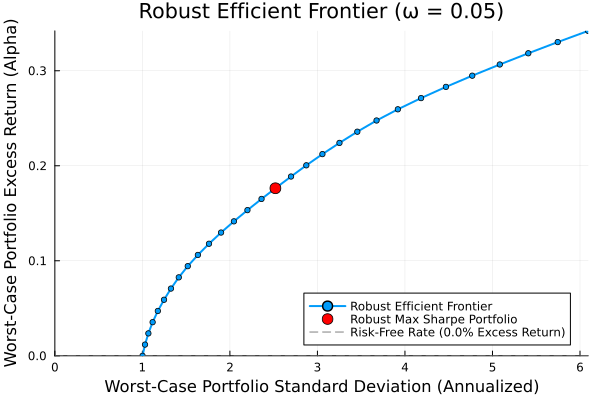

In [12]:
let 
    # Use the default GR backend for plotting
    gr()
    
    # Create the plot
    p = plot(
        frontier_std_dev_final, 
        frontier_returns_final,
        seriestype = :path,
        marker = :circle,
        markersize = 3,
        linewidth = 2,
        title = "Robust Efficient Frontier (ω = $ω)",
        xlabel = "Worst-Case Portfolio Standard Deviation (Annualized)",
        ylabel = "Worst-Case Portfolio Excess Return (Alpha)",
        label = "Robust Efficient Frontier",
        legend = :bottomright,
        # *** MODIFICATION HERE: Set x-axis to start at 0 ***
        xlims = (0, Inf),
        # *** MODIFICATION HERE: Set y-axis to start at 0 ***
        ylims = (0, Inf) 
    )
    
    # Add the Robust Max Sharpe Ratio portfolio to the plot
    scatter!(
        p,
        [robust_portfolio_plot_point[1]], # std dev
        [robust_portfolio_plot_point[2]], # excess return
        color = :red,
        markersize = 6,
        label = "Robust Max Sharpe Portfolio"
    )
    
    # The risk-free rate is now the 0.0 line on the excess return plot
    hline!(
        p,
        [0.0],
        linestyle = :dash,
        color = :grey,
        label = "Risk-Free Rate (0.0% Excess Return)"
    )
    
    display(p)
    
    # Save the plot to a file
    # savefig(p, "robust_efficient_frontier_growth_rates.pdf")

end;

### Step 13: Solve for the Classical Max Sharpe Portfolio
For comparison, we now solve the *classical* Markowitz portfolio problem. This is equivalent to our robust model but with all uncertainty parameters ($\gamma$ and $\rho$) set to zero. We use our "point estimates" ($\mu_0$, $V_0$, $F$, $\overline{D}$) as if they were the "true" parameters.

In [13]:
# --- 1. Define the Classical Covariance Matrix (Sigma) ---
# Σ = V₀*F*V₀' + D_bar
F_scalar = F
D_diag = Diagonal(D_bar)
V0_vec = V₀
Σ_classical = (V0_vec * F_scalar * V0_vec') + D_diag;

In [14]:
global ϕ_classical_normalized = Vector{Float64}()

# --- 2. Solve the Classical Max Sharpe Ratio Problem ---
model_classical = Model(SCS.Optimizer)
set_silent(model_classical)
@variable(model_classical, ϕ_c[1:n] >= 0)
@objective(model_classical, Min, ϕ_c' * Σ_classical * ϕ_c)
@constraint(model_classical, (μ₀)' * ϕ_c >= 1)
optimize!(model_classical)

# --- 3. Get the Normalized Classical Portfolio ---
if termination_status(model_classical) == OPTIMAL
    ϕ_classical_solution = value.(ϕ_c)
    
    # Assign the value to the global variable
    ϕ_classical_normalized = ϕ_classical_solution / sum(ϕ_classical_solution)
    
    println("\n--- Optimal Classical Portfolio Allocation ---")
    display(sort(DataFrame(Ticker=assets_to_use, Weight=ϕ_classical_normalized), :Weight, rev=true))
else
    println("Error: The classical model did not find an optimal solution.")
end


--- Optimal Classical Portfolio Allocation ---


Row,Ticker,Weight
,String,Float64
1,LLY,0.248433
2,NVDA,0.189948
3,CDNS,0.123394
4,PGR,0.088203
5,GLD,0.0822623
6,ORLY,0.064982
7,DPZ,0.0532891
8,TTWO,0.0479147
9,AVGO,0.0293563


### Step 14: Define Classical Frontier Helper Functions
This cell defines the helper functions needed to generate the comparison plot.
* `solve_classical_min_variance`: Solves the classical minimum variance problem (using `Σ_classical` and `μ₀`).
* `calculate_robust_stats`: Takes a portfolio and calculates its **worst-case** risk/return.
* `calculate_classical_stats`: Takes a portfolio and calculates its **optimistic (mean)** risk/return.

In [15]:
"""
Solves the CLASSICAL minimum variance problem for a given target *mean* return.
"""
function solve_classical_min_variance(target_return::Float64)
    model = Model(SCS.Optimizer)
    set_silent(model)
    
    @variable(model, ϕ[1:n] >= 0)
    
    # Objective: Minimize classical variance
    @objective(model, Min, ϕ' * Σ_classical * ϕ) 
    
    # Constraint 1: Weights sum to 1
    @constraint(model, sum(ϕ) == 1)
    
    # Constraint 2: *Mean* return must meet the target
    @constraint(model, (μ₀)' * ϕ >= target_return)
    
    optimize!(model)
    
    if termination_status(model) == OPTIMAL
        return value.(ϕ) # Return the optimal *portfolio*
    else
        return missing
    end
end

"""
Calculates the ROBUST (worst-case) stats for a given portfolio.
"""
function calculate_robust_stats(ϕ::Vector{Float64})
    # Worst-case return
    wc_return = (μ₀ - γ)' * ϕ
    
    # Worst-case std dev
    wc_factor_std = sqrt(F) * abs(V₀' * ϕ) + sqrt(κ) * (ρ' * ϕ)
    wc_residual_var = dot(ϕ, Diagonal(D_bar) * ϕ)
    wc_std_dev = sqrt(wc_factor_std^2 + wc_residual_var)
    
    return (wc_std_dev, wc_return)
end

"""
CalculTates the CLASSICAL (mean) stats for a given portfolio.
"""
function calculate_classical_stats(ϕ::Vector{Float64})
    classical_return = μ₀' * ϕ
    classical_var = ϕ' * Σ_classical * ϕ
    classical_std_dev = sqrt(classical_var)
    return (classical_std_dev, classical_return)
end;

### Step 15: Generate the Classical Frontier Comparison Data
This is a key step for visualization. We trace the classical efficient frontier by calling `solve_classical_min_variance` 30 times. For *each* classical portfolio $\phi_c$ we find, we calculate *two* sets of coordinates:
1.  **Optimistic View (Green Line):** Its expected risk/return, `(calculate_classical_stats(ϕ_c))`.
2.  **Robust View (Red Line):** Its worst-case risk/return, `(calculate_robust_stats(ϕ_c))`.

In [16]:
# Use the mean returns (alphas) as our target range
classical_mean_returns = μ₀
min_classical_ret = 0.0 # Start from 0%
max_classical_ret = maximum(classical_mean_returns)

# Create a range of targets
target_return_range_classical = range(min_classical_ret, max_classical_ret, length=30)

# Arrays to store the (x, y) coordinates for our plots
# Make them global so the plot cell can see them
global classical_optimistic_std = []
global classical_optimistic_ret = []
global classical_robust_std = []
global classical_robust_ret = []

# Loop, solve, and calculate stats
Threads.@threads for target_ret in target_return_range_classical
    ϕ_c = solve_classical_min_variance(target_ret)
    
    if !ismissing(ϕ_c)
        # 1. Get stats for the "Optimistic" plot
        (c_std, c_ret) = calculate_classical_stats(ϕ_c)
        push!(classical_optimistic_std, c_std)
        push!(classical_optimistic_ret, c_ret)
        
        # 2. Get stats for the "Robust" (worst-case) plot
        (r_std, r_ret) = calculate_robust_stats(ϕ_c)
        push!(classical_robust_std, r_std)
        push!(classical_robust_ret, r_ret)
    end
end;

### Step 16: Plot the Frontier Comparison
This plot visualizes the core concept of the paper. All three curves are plotted on the **Worst-Case Risk vs. Worst-Case Return** axes.

* **Blue Line (Robust Frontier):** The "true" efficient frontier.
* **Red Line (Classical - Robust View):** Where the classical portfolios *actually* land. It is "inside" the blue line, proving it's suboptimal.
* **Green Line (Classical - Optimistic View):** Where the classical model *thinks* its portfolios are. It is wildly optimistic and misleading.
* The plot also shows the tangent portfolios for both the robust (blue dot) and classical (red & green dots) models.

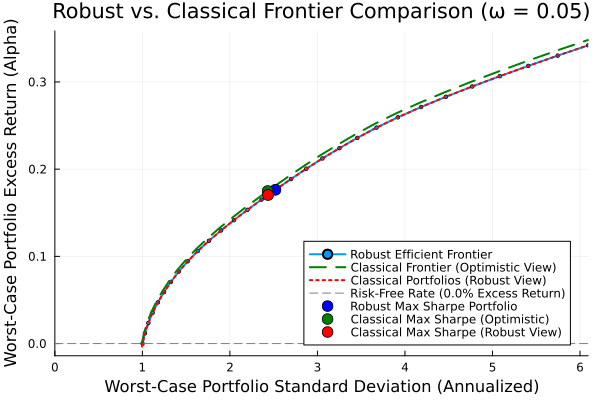

In [17]:
let
    
    # Use the default GR backend for plotting
    gr()
    
    # --- Calculate coordinates for the tangent portfolios ---

    # 2. Classical Max Sharpe Portfolio
    # Get its "Optimistic" (Classical) coordinates
    (classical_optimistic_std_tangent, classical_optimistic_ret_tangent) = calculate_classical_stats(ϕ_classical_normalized)
    # Get its "Robust" (Worst-Case) coordinates
    (classical_robust_std_tangent, classical_robust_ret_tangent) = calculate_robust_stats(ϕ_classical_normalized)
    
    
    # --- Plot the Frontiers ---
    
    # 1. Start with the Robust Frontier
    p_compare = plot(
        frontier_std_dev_final, 
        frontier_returns_final,
        seriestype = :path,
        marker = :circle,
        markersize = 2,
        linewidth = 2,
        title = "Robust vs. Classical Frontier Comparison (ω = $ω)",
        xlabel = "Worst-Case Portfolio Standard Deviation (Annualized)",
        ylabel = "Worst-Case Portfolio Excess Return (Alpha)",
        label = "Robust Efficient Frontier",
        legend = :bottomright,
        # *** MODIFICATION HERE: Set x-axis to start at 0 ***
        xlims = (0, Inf) 
    )
    
    # 2. Add the "Optimistic" Classical Frontier
    plot!(
        p_compare,
        classical_optimistic_std,
        classical_optimistic_ret,
        seriestype = :path,
        linewidth = 2,
        linestyle = :dash,
        color = :green,
        label = "Classical Frontier (Optimistic View)"
    )
    
    # 3. Add the "Robust View" of the Classical Portfolios
    plot!(
        p_compare,
        classical_robust_std,
        classical_robust_ret,
        seriestype = :path,
        linewidth = 2,
        linestyle = :dot,
        color = :red,
        label = "Classical Portfolios (Robust View)"
    )
    
    # 4. Add our reference lines
    hline!(
        p_compare,
        [0.0],
        linestyle = :dash,
        color = :grey,
        label = "Risk-Free Rate (0.0% Excess Return)"
    )
    
    # --- Plot the Tangent Portfolios ---
    
    # 1. Robust Max Sharpe (Blue Dot on Blue Line)
    scatter!(
        p_compare,
        [robust_portfolio_plot_point[1]], # std dev
        [robust_portfolio_plot_point[2]], # return
        color = :blue,
        markersize = 6,
        label = "Robust Max Sharpe Portfolio"
    )
    
    # 2. Classical Max Sharpe (Optimistic) (Green Dot on Green Line)
    scatter!(
        p_compare,
        [classical_optimistic_std_tangent],
        [classical_optimistic_ret_tangent],
        color = :green,
        markersize = 6,
        label = "Classical Max Sharpe (Optimistic)"
    )
    
    # 3. Classical Max Sharpe (Robust) (Red Dot on Red Line)
    scatter!(
        p_compare,
        [classical_robust_std_tangent],
        [classical_robust_ret_tangent],
        color = :red,
        markersize = 6,
        label = "Classical Max Sharpe (Robust View)"
    )
    
    display(p_compare)
    
    # Save the plot to a file
    # savefig(p_compare, joinpath(_PATH_TO_FIGS, "robust_vs_classical_frontier_comparison.pdf"))

end

### Step 17: Load Out-of-Sample (OOS) Test Data
We now load the held-out test dataset, which contains data from 2024 onward. To perform a fair comparison, we calculate two sets of returns for this test period:
1.  `test_return_matrix`: Daily *total* log-returns, used for simulating wealth accumulation.
2.  `test_growth_rates`: *Annualized excess* growth rates, used for calculating the OOS statistics.
3.  We also calculate both return series for our `SPY` benchmark.

In [18]:
# --- 1. Load the out-of-sample test data ---
# This function is from your notebook context
test_data_raw = MyOutOfSamplePortfolioDataSet()
test_dataset = test_data_raw["test_dataset"];

### Step 18: Simulate Out-of-Sample (OOS) Performance
We simulate the performance of our portfolios on the test data. We track the growth of $1 for the Robust Portfolio (`ϕ_robust_normalized`), the Classical Portfolio (`ϕ_classical_normalized`), the SPY benchmark, and the risk-free rate. The simulation uses the daily *total* log-returns to accurately model wealth compounding.

In [19]:

# --- 2. New function for daily (non-annualized) log returns ---
"""
Calculates the daily total log-return matrix (for wealth simulation).
"""
function get_daily_log_returns(dataset::Dict{String, DataFrame}, 
    firms::Array{String,1})::Array{Float64,2}

    number_of_firms = length(firms)
    number_of_trading_days = nrow(dataset[firms[1]])
    return_matrix = Array{Float64,2}(undef, number_of_trading_days-1, number_of_firms)

    for i ∈ eachindex(firms) 
        firm_index = firms[i]
        firm_data = dataset[firm_index]
        for j ∈ 2:number_of_trading_days
            S₁ = firm_data[j-1, :volume_weighted_average_price]
            S₂ = firm_data[j, :volume_weighted_average_price]
            return_matrix[j-1, i] = log(S₂/S₁)
        end
    end
    return return_matrix
end

# --- 3. Calculate BOTH return types for the test period ---

# (A) For wealth plot: Daily TOTAL log returns
global test_return_matrix = get_daily_log_returns(test_dataset, assets_to_use)
global num_test_days = size(test_return_matrix, 1)

# (B) For stats: Annualized EXCESS growth rates 
global test_growth_rates = log_return_matrix(test_dataset, assets_to_use, risk_free_rate = r_f_annual)

# *** ADD THIS PART: Get SPY's returns separately ***
global spy_test_return_matrix = get_daily_log_returns(test_dataset, [factor_ticker])
global spy_test_growth_rates = log_return_matrix(test_dataset, [factor_ticker], risk_free_rate = r_f_annual)


# Define the daily risk-free rate for comparison
global r_f_daily_log = log(1 + r_f_annual) / 252;

### Step 19: Calculate Out-of-Sample (OOS) Statistics
We calculate the final performance statistics for the test period. To remain consistent with our training model, the **OOS Sharpe Ratio** is calculated using the portfolio's stream of *annualized excess growth rates* (from `test_growth_rates`). We also calculate total return and annualized volatility for all three strategies.

In [20]:
# --- 1. Get portfolio's stream of *annualized excess returns* ---
robust_oos_returns = test_growth_rates * ϕ_robust_normalized
classical_oos_returns = test_growth_rates * ϕ_classical_normalized
spy_oos_returns = spy_test_growth_rates[:, 1]

# --- 2. Calculate Annualized Sharpe Ratios ---
function calculate_annualized_sharpe(annualized_excess_returns)
    mean_excess = mean(annualized_excess_returns)
    std_excess = std(annualized_excess_returns)
    # Annualize the daily-sampled ratio
    annualized_sharpe = (mean_excess / std_excess) * sqrt(252)
    return annualized_sharpe
end

sharpe_robust = calculate_annualized_sharpe(robust_oos_returns)
sharpe_classical = calculate_annualized_sharpe(classical_oos_returns)
sharpe_spy = calculate_annualized_sharpe(spy_oos_returns)

# --- 3. Get Daily Log Returns (For Volatility & Total Return) ---
robust_daily_log_returns = test_return_matrix * ϕ_robust_normalized
classical_daily_log_returns = test_return_matrix * ϕ_classical_normalized
spy_daily_log_returns = spy_test_return_matrix[:, 1]

# --- 4. Calculate Total Return (DIRECTLY) ---
total_return_robust = (exp(sum(robust_daily_log_returns)) - 1) * 100
total_return_classical = (exp(sum(classical_daily_log_returns)) - 1) * 100
total_return_spy = (exp(sum(spy_daily_log_returns)) - 1) * 100

# --- 5. Calculate Annualized Volatility ---
vol_robust = std(robust_daily_log_returns) * sqrt(252) * 100
vol_classical = std(classical_daily_log_returns) * sqrt(252) * 100
vol_spy = std(spy_daily_log_returns) * sqrt(252) * 100

# --- 6. Create DataFrame ---
stats_df = DataFrame(
    Metric = ["Out-of-Sample Sharpe Ratio", "Total Return (%)", "Annualized Volatility (%)"],
    Robust = [sharpe_robust, total_return_robust, vol_robust],
    Classical = [sharpe_classical, total_return_classical, vol_classical],
    SPY_Benchmark = [sharpe_spy, total_return_spy, vol_spy]
)

# --- 7. Print to Console and Save to File with Dynamic Name ---
# Convert ω to a string suitable for a filename
omega_str = replace(string(ω), "." => "")
table_filename = "oos_performance_table_omega_$(omega_str).txt"
output_table_path = joinpath(_PATH_TO_FIGS, table_filename)

# Define Formatter
float_formatter = (v, i, j) -> (typeof(v) <: Number) ? Printf.format(Printf.Format("%.2f"), v) : v

open(output_table_path, "w") do io
    # *** FIX: Include ω in the file header ***
    println(io, "--- Out-of-Sample Performance Comparison (ω = $ω) ---")
    pretty_table(
        io,
        stats_df,
        formatters = [float_formatter],
        alignment = :l
    )
end

println("\n--- Out-of-Sample Performance Comparison (ω = $ω) ---")
pretty_table(
    stats_df,
    formatters = [float_formatter],
    alignment = :l
)
println("Table saved to: ", output_table_path)


--- Out-of-Sample Performance Comparison (ω = 0.05) ---
┌────────────────────────────┬─────────┬───────────┬───────────────┐
│ Metric                     │ Robust  │ Classical │ SPY_Benchmark │
│ String                     │ Float64 │ Float64   │ Float64       │
├────────────────────────────┼─────────┼───────────┼───────────────┤
│ Out-of-Sample Sharpe Ratio │ 2.01    │ 2.05      │ 1.78          │
│ Total Return (%)           │ 57.91   │ 56.28     │ 27.60         │
│ Annualized Volatility (%)  │ 18.96   │ 18.15     │ 10.49         │
└────────────────────────────┴─────────┴───────────┴───────────────┘
Table saved to: /Users/abdulrahmanalswaidan/Desktop/CHEME 6800 Project/protfolio-optimizaton-project/figs/oos_performance_table_omega_005.txt


### Step 20: Plot Out-of-Sample (OOS) Performance


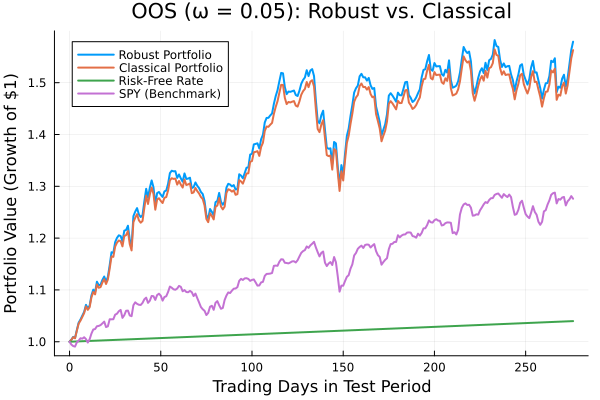

Plot saved to: /Users/abdulrahmanalswaidan/Desktop/CHEME 6800 Project/protfolio-optimizaton-project/figs/robust_vs_classical_performance_omega_005.pdf


In [21]:
# --- 1. Re-run the Simulation (Ensure fresh data) ---
# Initialize vectors
wealth_robust = ones(num_test_days + 1)
wealth_classical = ones(num_test_days + 1)
wealth_rf = ones(num_test_days + 1)
wealth_spy = ones(num_test_days + 1)

# Loop through test days
for t in 1:num_test_days
    # Get daily returns for each strategy
    r_robust = dot(ϕ_robust_normalized, test_return_matrix[t, :])
    r_classical = dot(ϕ_classical_normalized, test_return_matrix[t, :])
    r_spy = spy_test_return_matrix[t, 1]
    
    # Update wealth
    wealth_robust[t+1] = wealth_robust[t] * exp(r_robust)
    wealth_classical[t+1] = wealth_classical[t] * exp(r_classical)
    wealth_rf[t+1] = wealth_rf[t] * exp(r_f_daily_log)
    wealth_spy[t+1] = wealth_spy[t] * exp(r_spy)
end

# --- 2. Plot the Fresh Results with Dynamic Title ---
gr()
p_wealth = plot(
    0:num_test_days,
    [wealth_robust, wealth_classical, wealth_rf, wealth_spy],
    # *** FIX: Include ω in the title ***
    title = "OOS (ω = $ω): Robust vs. Classical",
    xlabel = "Trading Days in Test Period",
    ylabel = "Portfolio Value (Growth of \$1)",
    label = ["Robust Portfolio" "Classical Portfolio" "Risk-Free Rate" "SPY (Benchmark)"],
    legend = :topleft,
    linewidth = 2
)

display(p_wealth)

# *** FIX: Include ω in the filename ***
# Convert ω to a string suitable for a filename (e.g., 0.95 -> "095")
omega_str = replace(string(ω), "." => "")
filename = "robust_vs_classical_performance_omega_$(omega_str).pdf"

savefig(p_wealth, joinpath(_PATH_TO_FIGS, filename))
println("Plot saved to: ", joinpath(_PATH_TO_FIGS, filename))

### Step 21: Display Final Portfolio Allocations
Finally, we use `PrettyTables` to display the filtered (showing > 0.1%) portfolio weights for both the Robust and Classical solutions. This allows us to compare the allocations and see the total fraction of the portfolio that was invested.

In [22]:
# --- 1. Create the comparison DataFrame ---
df_compare = DataFrame(
    Ticker = assets_to_use, 
    Robust_Weight = ϕ_robust_normalized,
    Classical_Weight = ϕ_classical_normalized
)

# --- 2. Filter for weights > 1e-3 (0.1%) ---
df_filtered = filter(
    row -> row.Robust_Weight > 1e-3 || row.Classical_Weight > 1e-3, 
    df_compare
)
sort!(df_filtered, :Robust_Weight, rev=true)

# --- 3. Calculate TOTAL sum (should be ~1.0 or 100%) ---
total_robust_sum = sum(ϕ_robust_normalized)
total_classical_sum = sum(ϕ_classical_normalized)

# --- 4. Define the correct formatter ---
percent_formatter = (v, i, j) -> begin
    if j == 2 || j == 3
        return Printf.format(Printf.Format("%.3f%%"), v * 100)
    else
        return v
    end
end

# --- 5. Print to Console AND Save to File with Dynamic Name ---
# Convert ω to a string suitable for a filename
omega_str = replace(string(ω), "." => "")
alloc_filename = "portfolio_allocation_table_omega_$(omega_str).txt"
output_file_path = joinpath(_PATH_TO_FIGS, alloc_filename)

open(output_file_path, "w") do io
    # *** FIX: Include ω in the file header ***
    println(io, "--- Robust vs. Classical Allocation (ω = $ω, Showing > 0.1%) ---")
    
    # Write MAIN table to file
    pretty_table(
        io,
        df_filtered,
        column_labels = ["Asset Ticker", "Robust Weight", "Classical Weight"],
        formatters = [percent_formatter],
        alignment = :l
    )
    
    # Write spacing
    println(io, "")

    # Create a new DataFrame for the totals
    df_total = DataFrame(
        Label = ["TOTAL (All Assets)"],
        Robust_Total = [total_robust_sum],
        Classical_Total = [total_classical_sum]
    )

    # Write TOTALS table to file
    pretty_table(
        io,
        df_total,
        show_column_labels = false,
        formatters = [percent_formatter],
        alignment = :l
    )
end

# Also print to console for verification
println("\n--- Robust vs. Classical Allocation (ω = $ω, Showing > 0.1%) ---")
pretty_table(
    df_filtered,
    column_labels = ["Asset Ticker", "Robust Weight", "Classical Weight"],
    formatters = [percent_formatter],
    alignment = :l
)

# Print totals to console
df_total = DataFrame(
    Label = ["TOTAL (All Assets)"],
    Robust_Total = [total_robust_sum],
    Classical_Total = [total_classical_sum]
)
pretty_table(
    df_total,
    show_column_labels = false,
    formatters = [percent_formatter],
    alignment = :l
)

println("\nTable saved to: ", output_file_path)


--- Robust vs. Classical Allocation (ω = 0.05, Showing > 0.1%) ---
┌──────────────┬───────────────┬──────────────────┐
│ Asset Ticker │ Robust Weight │ Classical Weight │
├──────────────┼───────────────┼──────────────────┤
│ LLY          │ 25.766%       │ 24.843%          │
│ NVDA         │ 20.193%       │ 18.995%          │
│ CDNS         │ 13.170%       │ 12.339%          │
│ PGR          │ 8.785%        │ 8.820%           │
│ GLD          │ 6.442%        │ 8.226%           │
│ ORLY         │ 6.408%        │ 6.498%           │
│ DPZ          │ 5.005%        │ 5.329%           │
│ TTWO         │ 4.597%        │ 4.791%           │
│ AVGO         │ 3.161%        │ 2.936%           │
│ COST         │ 1.914%        │ 2.170%           │
│ RSG          │ 1.879%        │ 2.007%           │
│ EA           │ 1.845%        │ 2.297%           │
│ SNPS         │ 0.420%        │ 0.177%           │
│ AMD          │ 0.410%        │ 0.577%           │
└──────────────┴───────────────┴────────────────